
# Análise Exploratória — IPCA (1995–2022)

#### Este notebook realiza a análise exploratória da série temporal do IPCA,o índice oficial de inflação do Brasil.

#### O objetivo é entender o comportamento da série antes de partir para a modelagem.

#### **Dados:** Banco Central do Brasil — SGS, série 433
#### **Período:** Janeiro/1995 a Dezembro/2022
#### **Frequência:** Mensal

In [2]:
import pandas as pd
import matplotlib.pylab as plt

df = pd.read_csv('../data/processed/ipca_clean_20260411.csv', index_col=0)
df.index = pd.to_datetime(df.index)
df.head(336)

,ipca_pct
Date,
1995-01-01,1.70
1995-02-01,1.02
1995-03-01,1.55
1995-04-01,2.43
1995-05-01,2.67
...,...
2022-08-01,-0.36
2022-09-01,-0.29
2022-10-01,0.59


# 1. Estatísticas Descritivas

#### Visão geral do comportamento central e dispersão da série.

In [1]:
df.describe()

NameError: name 'df' is not defined

# **Interpretação:**
#### - Média de **0.55% ao mês** (~6.6% ao ano) — condizente com a realidade brasileira no período
#### - Mediana (0.47%) abaixo da média (0.55%) — distribuição com cauda direita, puxada por picos de inflação
#### - Desvio padrão de 0.47% — alta variabilidade em relação à média
#### - Mínimo de **-0.68%** (deflação em jul/2022) e máximo de **3.02%** (nov/2002 — crise cambial)

# 2. Série Temporal Completa
#### Visualização da série ao longo do tempo para identificar tendência,sazonalidade e eventos extremos.

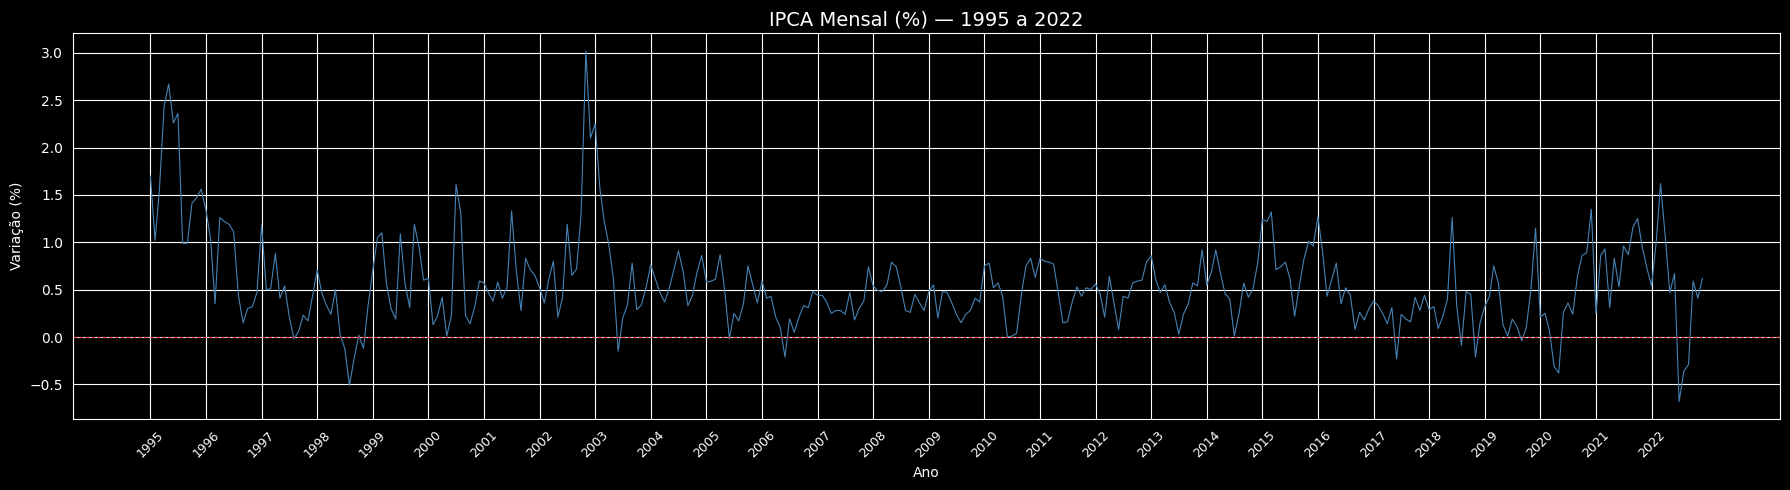

In [14]:
fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(df.index, df["ipca_pct"], color="steelblue", linewidth=0.8)

anos = df[df.index.month == 1].index
ax.set_xticks(anos)
ax.set_xticklabels([d.strftime("%Y") for d in anos], rotation=45, fontsize=9)

ax.axhline(0, color="red", linewidth=0.8, linestyle="--", alpha=0.7)

ax.set_title("IPCA Mensal (%) — 1995 a 2022", fontsize=14)
ax.set_xlabel("Ano")
ax.set_ylabel("Variação (%)")
plt.tight_layout()
plt.show()

# **Interpretação:**
#### - Inflação elevada entre **1995–1999**, período de estabilização pós-Plano Real
####  - Pico em **2002** (crise cambial pré-eleição) e **2015–2016** (recessão)
####  - Alta acentuada em **2021–2022** (pandemia, guerra e pressão de commodities)
#### - Valores negativos em **2020** (pandemia) e **2022** (desonerações de combustível)

# 3. Qualidade dos Dados

In [5]:
print("Nulos:", df["ipca_pct"].isnull().sum())
print("Frequência do índice:", pd.infer_freq(df.index))
print("Total de observações:", len(df))

Nulos: 0
Frequência do índice: MS
Total de observações: 336


# **Interpretação:**
#### - Sem valores nulos — série completa e sem gaps
#### - Frequência mensal regular confirmada (`MS`)
#### - 336 observações (28 anos × 12 meses)

# 4. Sazonalidade por Mês

#### Distribuição dos valores por mês do ano para identificar padrões sazonais recorrentes.


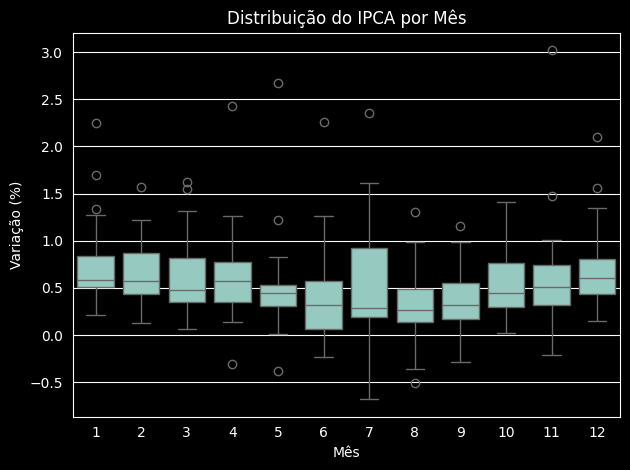

In [6]:

import seaborn as sns

df["mes"] = df.index.month

sns.boxplot(data=df, x="mes", y="ipca_pct")
plt.title("Distribuição do IPCA por Mês")
plt.xlabel("Mês")
plt.ylabel("Variação (%)")
plt.tight_layout()
plt.show()

df.drop(columns=["mes"], inplace=True)

# **Interpretação:**
#### - Sazonalidade moderada — janeiro, março e abril com medianas mais altas por reajustes anuais de energia, educação e planos de saúde
#### - Junho e julho tendem a ser mais brandos historicamente
#### - Outliers presentes em todos os meses — choques externos afetam a série independentemente da época do ano



# 5. Decomposição da Série

#### Separação da série em seus componentes: tendência, sazonalidade e resíduo.

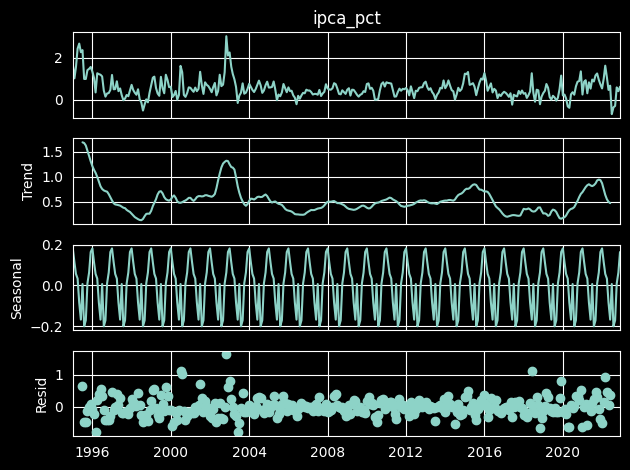

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(df["ipca_pct"], model="additive", period=12)
decomposicao.plot()
plt.tight_layout()
plt.show()

# **Interpretação:**
#### - **Tendência:** ciclos econômicos visíveis — queda pós-1995, alta em 2002,estabilidade 2006–2013, alta 2015–2016 e novo pico em 2021–2022
#### - **Sazonalidade:** padrão anual consistente, confirmando o boxplot anterior
#### - **Resíduo:** choques pontuais isolados — eventos não explicados pelo modelo de decomposição

# 6. Teste de Estacionariedade (ADF)

#### O ARIMA exige que a série seja estacionária — média e variância constantes ao longo do tempo. O teste ADF verifica essa condição.
#### - **H0 (hipótese nula):** a série possui raiz unitária (não estacionária)
#### - **Rejeitar H0** (p-valor ≤ 0.05) → série estacionária

In [8]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df["ipca_pct"].dropna())

print("Estatística ADF:", resultado[0])
print("p-valor:", resultado[1])
print("Lags utilizados:", resultado[2])
print("Observações:", resultado[3])
print("\nValores críticos:")
for key, value in resultado[4].items():
    print(f"  {key}: {value:.4f}")

if resultado[1] <= 0.05:
    print("\n✅ Série estacionária (rejeita H0)")
else:
    print("\n❌ Série NÃO estacionária (falha em rejeitar H0)")

Estatística ADF: -7.954957051503967
p-valor: 3.0547953166209468e-12
Lags utilizados: 0
Observações: 335

Valores críticos:
  1%: -3.4500
  5%: -2.8702
  10%: -2.5714

✅ Série estacionária (rejeita H0)


# **Interpretação:**

**Resultado:**
- Estatística ADF: -7.95 | p-valor: 3.05e-12
- Muito abaixo do valor crítico de 1% (-3.45)
- ✅ Série já é estacionária — **d = 0** no ARIMA
- Não é necessário aplicar diferenciação

# 7. ACF e PACF

#### Os gráficos de autocorrelação guiam a escolha dos parâmetros p e q do ARIMA:
#### - **PACF** → sugere o parâmetro **p** (componente AR)
#### - **ACF** → sugere o parâmetro **q** (componente MA)

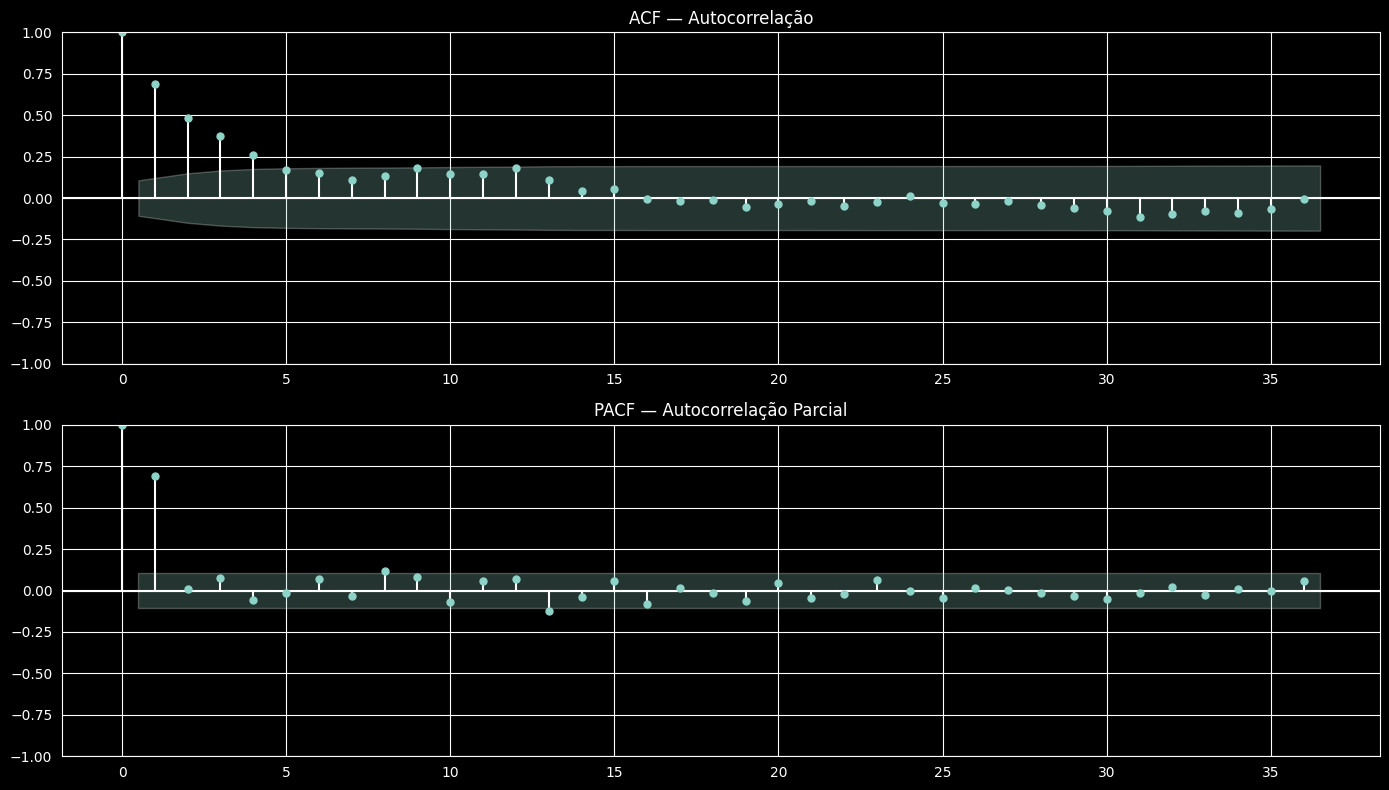

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df["ipca_pct"].dropna(), lags=36, ax=axes[0])
axes[0].set_title("ACF — Autocorrelação")

plot_pacf(df["ipca_pct"].dropna(), lags=36, ax=axes[1])
axes[1].set_title("PACF — Autocorrelação Parcial")

plt.tight_layout()
plt.show()

**Resultado:**

- PACF: spike significativo no lag 1 (~0.70), corte abrupto → **p = 1**
- ACF: decaimento gradual ao longo de ~10 lags → **q = 1**
- Parâmetros iniciais sugeridos: **ARIMA(1, 0, 1)**
- O `auto_arima` será usado para confirmar na fase de modelagem

# 8. Média Móvel — Suavização da Tendência

#### A média móvel de 12 meses remove o ruído mensal e evidencia a tendência de longo prazo da série.

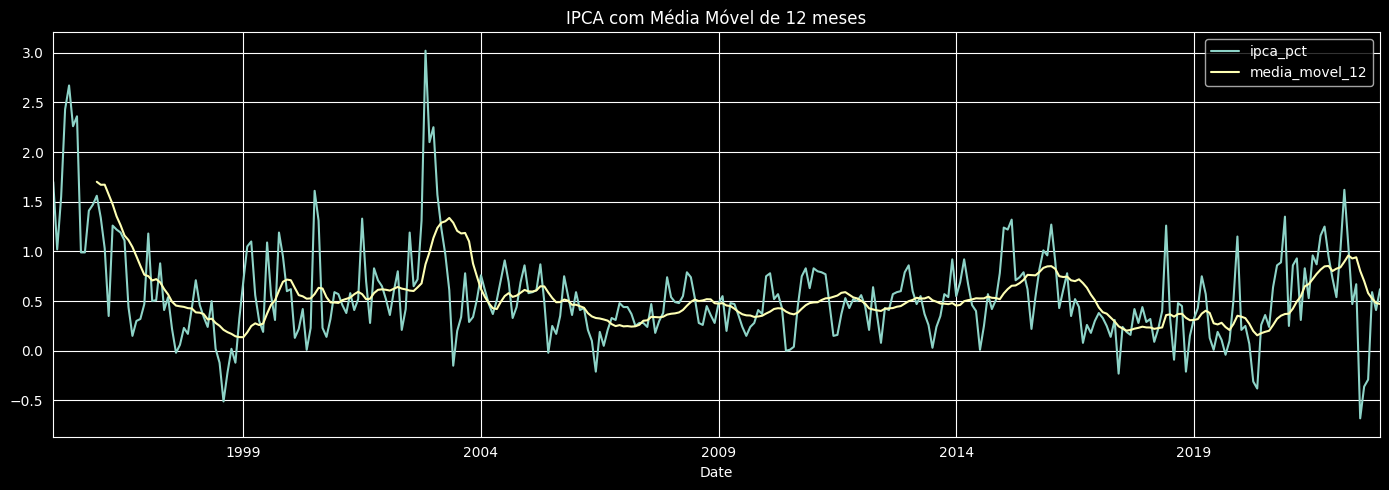

In [10]:
df["media_movel_12"] = df["ipca_pct"].rolling(window=12).mean()

df[["ipca_pct", "media_movel_12"]].plot(figsize=(14, 5), title="IPCA com Média Móvel de 12 meses")
plt.tight_layout()
plt.show()

df.drop(columns=["media_movel_12"], inplace=True)

# **Interpretação:**
#### - A média móvel confirma os ciclos econômicos identificados na decomposição
#### - Períodos onde a série original se afasta muito da média móvel indicam choques pontuais que o modelo pode ter dificuldade em prever

# 9. Conclusões da EDA

#### | Aspecto | Conclusão |

#### | Nulos | Nenhum — série completa |
#### | Frequência | Mensal regular (`MS`) |
#### | Sazonalidade | Moderada — mais forte em jan/mar/abr |
#### | Estacionariedade | Estacionária — p-valor = 3.05e-12 |
#### | Parâmetro d (ARIMA) | d = 0 |
#### | Parâmetros p e q | p = 1, q = 1 — ARIMA(1, 0, 1 |
#### | Outliers relevantes | nov/2002, 2015–2016, 2021–2022 |